# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [2]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [3]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [4]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [5]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


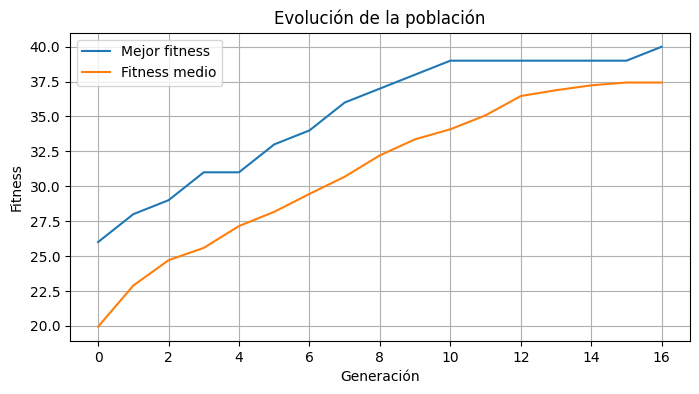

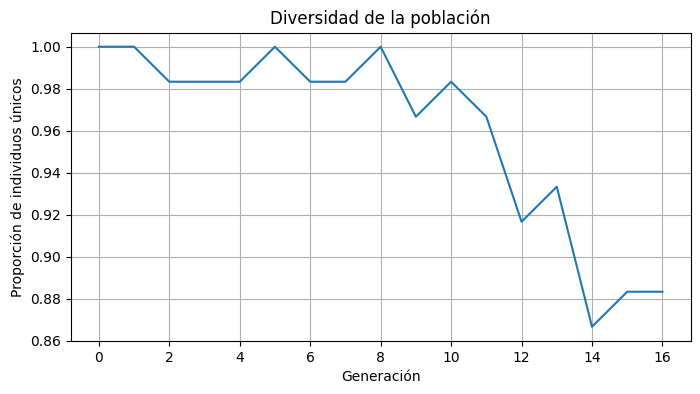

In [6]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [7]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [8]:
def roulette_selection(population, rng):
    fitnesses = [fitness(ind) for ind in population]
    total = sum(fitnesses)

    if total == 0:
        return rng.choice(population).copy()

    pick = rng.uniform(0, total)
    acumulado = 0
    for individual, fit in zip(population, fitnesses):
        acumulado += fit
        if acumulado >= pick:
            return individual.copy()

    return population[-1].copy()  # fallback por errores de redondeo flotante

# Prueba rapida
sample_population = [create_individual(12, rng) for _ in range(8)]
selected = roulette_selection(sample_population, rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 000010010011 fitness = 4


### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [9]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1, child2 = [], []
    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)

    return child1, child2

# Prueba rapida
p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = uniform_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11000101
Hijo 2 : 00111010


### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

In [10]:
import string

TARGET = "INTELIGENCIA ARTIFICIAL"
ALPHABET = string.ascii_uppercase + " "

def create_individual_phrase(length, rng):
    return [rng.choice(ALPHABET) for _ in range(length)]

def fitness_phrase(individual, target=TARGET):
    return sum(1 for a, b in zip(individual, target) if a == b)

def as_string_phrase(individual):
    return ''.join(individual)

def mutate_phrase(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = rng.choice(ALPHABET)
    return child

def tournament_selection_phrase(population, tournament_size, rng, target=TARGET):
    # Version de tournament_selection que usa fitness_phrase en lugar de fitness
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=lambda ind: fitness_phrase(ind, target)).copy()

def genetic_algorithm_phrase(
    target=TARGET,
    population_size=200,
    generations=500,
    crossover_rate=0.9,
    mutation_rate=0.02,
    tournament_size=3,
    elitism=True,
    seed=0
):
    length = len(target)
    rng = random.Random(seed)
    population = [create_individual_phrase(length, rng) for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness_phrase(ind, target) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'best_individual': best
        })

        if fitness_phrase(best, target) == length or generation == generations:
            break

        new_population = [best] if elitism else []
        while len(new_population) < population_size:
            parent1 = tournament_selection_phrase(population, tournament_size, rng, target)
            parent2 = tournament_selection_phrase(population, tournament_size, rng, target)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate_phrase(child1, mutation_rate, rng)
            child2 = mutate_phrase(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return best, history

best_phrase, hist_phrase = genetic_algorithm_phrase(seed=1)
print(as_string_phrase(best_phrase), '| fitness =', hist_phrase[-1]['best'], '/', len(TARGET))
print('Generaciones ejecutadas:', hist_phrase[-1]['generation'])

INTELIGENCIA ARTIFICIAL | fitness = 23 / 23
Generaciones ejecutadas: 37


### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

Con elitismo (generacion, mejor fitness):
0 27
1 29
2 30
3 30
4 33
5 34
6 34
7 36
8 36
9 36
10 37
11 39
12 39
13 39
14 39
15 39
16 40

Sin elitismo (generacion, mejor fitness):
0 27
1 29
2 29
3 31
4 32
5 34
6 34
7 35
8 36
9 38
10 37
11 38
12 39
13 38
14 39
15 39
16 39
17 39
18 40


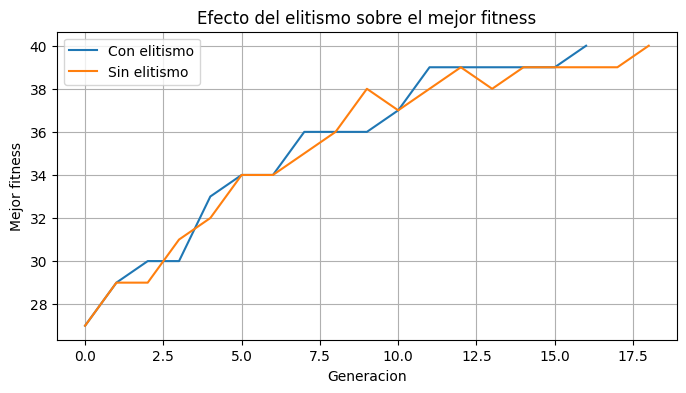

In [11]:
_, hist_con_elitismo = genetic_algorithm(elitism=True, seed=7)
_, hist_sin_elitismo = genetic_algorithm(elitism=False, seed=7)

print('Con elitismo (generacion, mejor fitness):')
for h in hist_con_elitismo:
    print(h['generation'], h['best'])

print()
print('Sin elitismo (generacion, mejor fitness):')
for h in hist_sin_elitismo:
    print(h['generation'], h['best'])

plt.figure(figsize=(8, 4))
plt.plot([h['generation'] for h in hist_con_elitismo], [h['best'] for h in hist_con_elitismo], label='Con elitismo')
plt.plot([h['generation'] for h in hist_sin_elitismo], [h['best'] for h in hist_sin_elitismo], label='Sin elitismo')
plt.xlabel('Generacion')
plt.ylabel('Mejor fitness')
plt.title('Efecto del elitismo sobre el mejor fitness')
plt.legend()
plt.grid(True)
plt.show()

**Respuesta:** Si, con `elitism=False` el mejor fitness *puede* disminuir de una generacion a la siguiente. Esto ocurre porque, sin elitismo, el mejor individuo de la generacion actual solo sobrevive a la siguiente si es seleccionado por el torneo y, ademas, no es alterado de forma negativa por el cruce o la mutacion. No hay ningun mecanismo que garantice su paso directo. Con elitismo, en cambio, el mejor individuo se copia sin cambios a la siguiente generacion, por lo que el mejor fitness es monotono no decreciente por construccion.

## Preguntas de cierre

1. ¿Qué papel cumple la población que no existe en Hill Climbing?
2. ¿Por qué el cruce no garantiza hijos mejores que sus padres?
3. ¿Qué significa convergencia prematura?
4. ¿Qué parámetros controlan la exploración?

## Respuestas — Preguntas de cierre

1. **¿Que papel cumple la poblacion que no existe en Hill Climbing?**
   Hill Climbing mantiene un unico estado y solo explora su vecindario inmediato, por lo que queda expuesto a quedar atrapado en optimos locales. La poblacion de un AG mantiene multiples soluciones en paralelo, permitiendo explorar varias regiones del espacio de busqueda al mismo tiempo y recombinar informacion genetica entre individuos, algo que Hill Climbing no puede hacer al no tener otro individuo con quien cruzarse.

2. **¿Por que el cruce no garantiza hijos mejores que sus padres?**
   El cruce combina fragmentos de dos padres, pero esa combinacion puede romper interacciones favorables entre genes (epistasis) o juntar dos fragmentos mediocres. Es una operacion exploratoria sin garantia direccional: puede producir hijos mejores, iguales o peores que sus padres.

3. **¿Que significa convergencia prematura?**
   Es cuando la poblacion pierde diversidad genetica demasiado rapido y todos los individuos se concentran alrededor de un optimo local, sin material genetico suficiente para escapar de el. El algoritmo "converge", pero a una solucion subóptima.

4. **¿Que parametros controlan la exploracion?**
   El tamaño del torneo (mas grande implica mayor presion selectiva y menos exploracion), la tasa de mutacion (mas alta favorece mas exploracion/diversidad), la tasa de cruce, el tamaño de la poblacion y el uso o no de elitismo.